## 1. Load Dataset and Initial Exploration

In [33]:
import pandas as pd


df = pd.read_csv('/content/Curriculum_Industry_Skill_Alignment.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include='all'))

print("\nMissing values in each column:")
display(df.isnull().sum()[df.isnull().sum() > 0])

First 5 rows of the dataset:


,Student_ID,Gender,Semester,CGPA,Programming,DSA,DBMS,OS,CN,OOP,...,AI_ML,Communication,Aptitude,Teamwork,Problem_Solving,Internship,Certifications,Projects_Completed,Placement_Status,Industry_Readiness
0,S001,Female,7,8.43,3,7,6,6,5,4,...,6,6,3,6,9,Yes,3,5,Not Placed,Not Ready
1,S002,Female,7,8.88,5,9,8,7,5,6,...,8,8,7,3,10,Yes,3,1,Placed,Ready
2,S003,Male,7,8.68,3,6,7,4,6,4,...,8,8,6,7,4,Yes,4,6,Not Placed,Not Ready
3,S004,Male,8,7.76,7,6,8,3,6,3,...,8,6,10,9,10,Yes,2,2,Not Placed,Not Ready
4,S005,Male,8,8.84,9,9,8,6,5,10,...,9,4,9,9,10,No,4,1,Not Placed,Not Ready



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    object 
 1   Gender              100 non-null    object 
 2   Semester            100 non-null    int64  
 3   CGPA                100 non-null    float64
 4   Programming         100 non-null    int64  
 5   DSA                 100 non-null    int64  
 6   DBMS                100 non-null    int64  
 7   OS                  100 non-null    int64  
 8   CN                  100 non-null    int64  
 9   OOP                 100 non-null    int64  
 10  Python              100 non-null    int64  
 11  Java                100 non-null    int64  
 12  SQL                 100 non-null    int64  
 13  Web_Development     100 non-null    int64  
 14  Cloud               100 non-null    int64  
 15  AI_ML               100 non-null    

,Student_ID,Gender,Semester,CGPA,Programming,DSA,DBMS,OS,CN,OOP,...,AI_ML,Communication,Aptitude,Teamwork,Problem_Solving,Internship,Certifications,Projects_Completed,Placement_Status,Industry_Readiness
count,100,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,...,100.000000,100.00000,100.000000,100.000000,100.000000,100,100.000000,100.000000,100,100
unique,100,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,2,2
top,S001,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,Not Placed,Not Ready
freq,1,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,63,NaN,NaN,95,94
mean,NaN,NaN,7.540000,8.097900,6.650000,6.370000,6.470000,6.39000,6.280000,6.530000,...,6.630000,6.47000,6.490000,6.550000,6.680000,NaN,2.690000,3.490000,NaN,NaN
std,NaN,NaN,0.500908,1.070257,2.257982,2.263701,2.409807,2.36513,2.252182,2.434827,...,2.368373,2.31139,2.359143,2.266912,2.448995,NaN,1.637286,1.817396,NaN,NaN
min,NaN,NaN,7.000000,6.060000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,...,3.000000,3.00000,3.000000,3.000000,3.000000,NaN,0.000000,1.000000,NaN,NaN
25%,NaN,NaN,7.000000,7.200000,5.000000,4.750000,4.000000,4.00000,4.750000,4.000000,...,4.000000,4.75000,4.000000,5.000000,4.000000,NaN,1.000000,2.000000,NaN,NaN
50%,NaN,NaN,8.000000,8.105000,7.000000,6.000000,6.000000,6.00000,6.000000,6.000000,...,7.000000,7.00000,6.500000,6.500000,7.000000,NaN,3.000000,3.000000,NaN,NaN
75%,NaN,NaN,8.000000,8.987500,9.000000,8.000000,8.250000,9.00000,8.000000,9.000000,...,9.000000,8.00000,8.000000,9.000000,9.000000,NaN,4.000000,5.000000,NaN,NaN



Missing values in each column:


,0


### Correlation Heatmap of Numerical Features


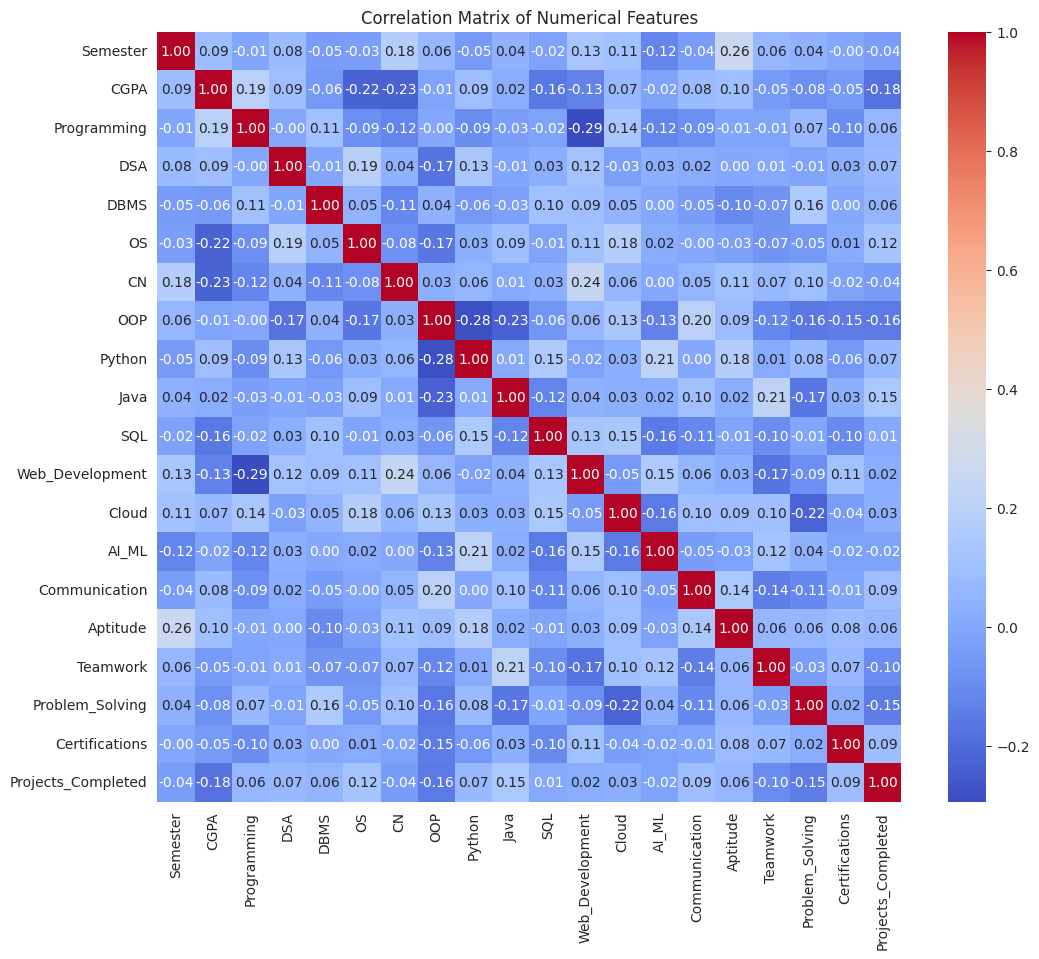

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

print("### Correlation Heatmap of Numerical Features")

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df.drop(["Student_ID", "Industry_Readiness", "Placement_Status"], axis=1)
y = df["Industry_Readiness"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

In [37]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

X = df.drop(["Student_ID", "Industry_Readiness", "Placement_Status"], axis=1)
y = df["Industry_Readiness"]


le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_labels = le.classes_


categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


X_processed = preprocessor.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Accuracy: 0.90


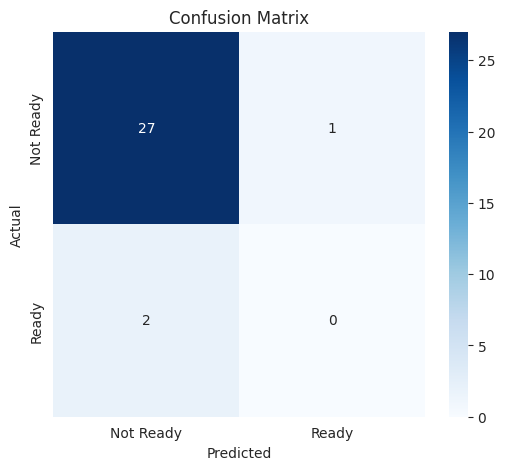


Classification Report:
              precision    recall  f1-score   support

   Not Ready       0.93      0.96      0.95        28
       Ready       0.00      0.00      0.00         2

    accuracy                           0.90        30
   macro avg       0.47      0.48      0.47        30
weighted avg       0.87      0.90      0.88        30



In [39]:

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

report = classification_report(y_test, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(report)